## Imports et configuration générale

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.optimize import minimize_scalar

## Basic tools

In [4]:
METHODS = (
    "raw_on_interp",
    "interp_on_raw",
    "interp_on_interp",
    "combined",
)

METHOD_LABELS = {
    "raw_on_interp": "A brut sur B interpolé",
    "interp_on_raw": "A interpolé sur B brut",
    "interp_on_interp": "A interpolé sur B interpolé",
    "combined": "Moyenne des trois méthodes",
}


def robust_normalize(y, s, sigma_floor=0.05):
    """
    Robust independent normalization of one light curve.

        y_norm = (y - median(y)) / (1.4826 * MAD(y))
        s_norm = s / scale
    """
    y = np.asarray(y, float)
    s = np.asarray(s, float)

    med = float(np.nanmedian(y))
    mad = float(np.nanmedian(np.abs(y - med)))
    scale = 1.4826 * mad

    if not np.isfinite(scale) or scale <= 1e-12:
        scale = float(np.nanstd(y))

    if not np.isfinite(scale) or scale <= 1e-12:
        scale = 1.0

    y_norm = (y - med) / scale
    s_norm = np.maximum(s / scale, float(sigma_floor))

    return y_norm, s_norm, med, scale


def weighted_mean(x, variance):
    x = np.asarray(x, float)
    variance = np.asarray(variance, float)

    ok = np.isfinite(x) & np.isfinite(variance) & (variance > 0)

    if not np.any(ok):
        return np.nan

    w = 1.0 / variance[ok]
    sw = np.sum(w)

    if not np.isfinite(sw) or sw <= 0:
        return np.nan

    return float(np.sum(w * x[ok]) / sw)


def _aggregate_duplicate_times(t, y, s):
    """
    Merge duplicate epochs with an inverse-variance weighted mean.
    This makes classical linear interpolation well defined.
    """
    t = np.asarray(t, float)
    y = np.asarray(y, float)
    s = np.asarray(s, float)

    ok = np.isfinite(t) & np.isfinite(y) & np.isfinite(s) & (s > 0)
    t, y, s = t[ok], y[ok], s[ok]

    if len(t) == 0:
        return t, y, s

    order = np.argsort(t)
    t, y, s = t[order], y[order], s[order]

    unique_t, inv = np.unique(t, return_inverse=True)

    if len(unique_t) == len(t):
        return t, y, s

    w = 1.0 / np.maximum(s ** 2, 1e-24)
    sum_w = np.bincount(inv, weights=w, minlength=len(unique_t))
    sum_wy = np.bincount(inv, weights=w * y, minlength=len(unique_t))

    y_new = sum_wy / np.maximum(sum_w, 1e-24)
    s_new = np.sqrt(1.0 / np.maximum(sum_w, 1e-24))

    return unique_t, y_new, s_new


def linear_interp_with_error(x, y, s, x_new):
    """
    Classical piecewise-linear interpolation, with no extrapolation.

    For x_new between x_j and x_{j+1}:
        y_interp = (1-a) y_j + a y_{j+1}

    Assuming independent endpoint errors:
        var_interp = (1-a)^2 s_j^2 + a^2 s_{j+1}^2

    Returns
    -------
    y_new, s_new, valid
    """
    x, y, s = _aggregate_duplicate_times(x, y, s)
    x_new = np.asarray(x_new, float)

    y_new = np.full(x_new.shape, np.nan, dtype=float)
    s_new = np.full(x_new.shape, np.nan, dtype=float)
    valid = np.zeros(x_new.shape, dtype=bool)

    if len(x) < 2:
        return y_new, s_new, valid

    valid = np.isfinite(x_new) & (x_new >= x[0]) & (x_new <= x[-1])

    if not np.any(valid):
        return y_new, s_new, valid

    xv = x_new[valid]
    right = np.searchsorted(x, xv, side="right")
    right = np.clip(right, 1, len(x) - 1)
    left = right - 1

    x0 = x[left]
    x1 = x[right]
    dx = x1 - x0

    alpha = np.divide(
        xv - x0,
        dx,
        out=np.zeros_like(xv),
        where=np.abs(dx) > 0,
    )
    alpha = np.clip(alpha, 0.0, 1.0)

    yv = (1.0 - alpha) * y[left] + alpha * y[right]
    varv = (1.0 - alpha) ** 2 * s[left] ** 2 + alpha ** 2 * s[right] ** 2

    y_new[valid] = yv
    s_new[valid] = np.sqrt(np.maximum(varv, 0.0))

    return y_new, s_new, valid

## Data extraction

In [5]:
def get_curve(group):
    t = pd.to_numeric(group["epoch_obs_jd"], errors="coerce").to_numpy(float)
    y = pd.to_numeric(group["flux_obs"], errors="coerce").to_numpy(float)
    s = pd.to_numeric(group["flux_obs_error"], errors="coerce").to_numpy(float)

    ok = np.isfinite(t) & np.isfinite(y) & np.isfinite(s) & (s > 0)
    t, y, s = t[ok], y[ok], s[ok]

    order = np.argsort(t)
    return t[order], y[order], s[order]


def get_pair_from_df(df, source_id, comp_a, comp_b, names=("A reference", "B")):
    """
    Extract exactly two light curves.
    The delay convention is:

        t_B_shifted = t_B - delay

    Therefore delay > 0 means that B is observed later than A.
    """
    if len(names) != 2:
        raise ValueError("names must contain exactly two labels.")

    group = df[df["source_id"] == source_id]

    curves = []
    for comp_id, name in zip((comp_a, comp_b), names):
        cg = group[group["lensComponentSourceId"] == comp_id]
        t, y, s = get_curve(cg)

        if len(t) < 2:
            raise ValueError(f"Not enough valid points for component {comp_id} / {name}.")

        curves.append({
            "source_id": source_id,
            "comp_id": comp_id,
            "name": str(name),
            "t": t,
            "y": y,
            "s": s,
        })

    return {
        "source_id": source_id,
        "comp_ids": [comp_a, comp_b],
        "names": list(names),
        "curves": curves,
    }


def prepare_pair(curves, sigma_floor=0.05):
    if len(curves) != 2:
        raise ValueError("This interpolation estimator requires exactly two curves.")

    t0 = min(float(np.min(curves[0]["t"])), float(np.min(curves[1]["t"])))
    prepared = []

    for curve in curves:
        t = np.asarray(curve["t"], float) - t0
        y_raw = np.asarray(curve["y"], float)
        s_raw = np.asarray(curve["s"], float)

        y, s, median, scale = robust_normalize(
            y_raw,
            s_raw,
            sigma_floor=sigma_floor,
        )

        t, y, s = _aggregate_duplicate_times(t, y, s)

        prepared.append({
            "source_id": curve.get("source_id"),
            "comp_id": curve.get("comp_id"),
            "name": curve.get("name", f"curve_{len(prepared)}"),
            "t": t,
            "y": y,
            "s": s,
            "median_raw": median,
            "scale_raw": scale,
            "t0": t0,
        })

    return prepared

## Scores for one candidate delay

In [6]:
def _overlap_information(curve_a, curve_b, delay):
    ta = np.asarray(curve_a["t"], float)
    tb_shift = np.asarray(curve_b["t"], float) - float(delay)

    start = max(float(np.min(ta)), float(np.min(tb_shift)))
    end = min(float(np.max(ta)), float(np.max(tb_shift)))

    if end <= start:
        return None

    mask_a = (ta >= start) & (ta <= end)
    mask_b = (tb_shift >= start) & (tb_shift <= end)

    span_a = max(float(np.max(ta) - np.min(ta)), 1e-12)
    span_b = max(float(np.max(tb_shift) - np.min(tb_shift)), 1e-12)

    return {
        "tb_shift": tb_shift,
        "start": start,
        "end": end,
        "mask_a": mask_a,
        "mask_b": mask_b,
        "n_a": int(np.sum(mask_a)),
        "n_b": int(np.sum(mask_b)),
        "frac_a": float(np.mean(mask_a)),
        "frac_b": float(np.mean(mask_b)),
        "span_frac": float((end - start) / min(span_a, span_b)),
    }


def _score_residuals(y_left, y_right, s_left, s_right, fit_offset=True):
    y_left = np.asarray(y_left, float)
    y_right = np.asarray(y_right, float)
    s_left = np.asarray(s_left, float)
    s_right = np.asarray(s_right, float)

    variance = s_left ** 2 + s_right ** 2
    ok = (
        np.isfinite(y_left)
        & np.isfinite(y_right)
        & np.isfinite(variance)
        & (variance > 0)
    )

    if np.sum(ok) < 2:
        return {
            "score": np.inf,
            "offset": np.nan,
            "residuals": np.array([]),
            "variance": np.array([]),
            "n": int(np.sum(ok)),
        }

    delta = y_left[ok] - y_right[ok]
    var = variance[ok]

    if fit_offset:
        offset = weighted_mean(delta, var)
    else:
        offset = 0.0

    if not np.isfinite(offset):
        return {
            "score": np.inf,
            "offset": np.nan,
            "residuals": np.array([]),
            "variance": np.array([]),
            "n": int(np.sum(ok)),
        }

    residuals = delta - offset
    chi2_terms = residuals ** 2 / var
    score = float(np.mean(chi2_terms))

    return {
        "score": score,
        "offset": float(offset),
        "residuals": residuals,
        "variance": var,
        "n": len(residuals),
        "chi2": float(np.sum(chi2_terms)),
    }


def evaluate_delay_linear_interpolation(
    curves,
    delay,
    common_grid_size=200,
    fit_offset=True,
    min_points=10,
    min_frac=0.50,
    min_span_frac=0.50,
    overlap_penalty=0.0,
):
    """
    Evaluate the three requested classical linear-interpolation methods.

    1. raw_on_interp:
       raw A points compared with linearly interpolated B.

    2. interp_on_raw:
       linearly interpolated A compared with raw B points.

    3. interp_on_interp:
       A and B both linearly interpolated on the same regular overlap grid.

    No spline is constructed anywhere.
    """
    if len(curves) != 2:
        raise ValueError("Exactly two curves are required.")

    a, b = curves
    info = _overlap_information(a, b, delay)

    invalid = {
        "delay": float(delay),
        "raw_on_interp": {"score": np.inf},
        "interp_on_raw": {"score": np.inf},
        "interp_on_interp": {"score": np.inf},
        "combined": {"score": np.inf},
        "valid": False,
    }

    if info is None:
        return invalid

    if info["n_a"] < int(min_points) or info["n_b"] < int(min_points):
        return invalid

    if min(info["frac_a"], info["frac_b"]) < float(min_frac):
        return invalid

    if info["span_frac"] < float(min_span_frac):
        return invalid

    ta = np.asarray(a["t"], float)
    ya = np.asarray(a["y"], float)
    sa = np.asarray(a["s"], float)

    tb = np.asarray(info["tb_shift"], float)
    yb = np.asarray(b["y"], float)
    sb = np.asarray(b["s"], float)

    ma = info["mask_a"]
    mb = info["mask_b"]

    # --------------------------------------------------------
    # 1) A raw on B interpolated
    # --------------------------------------------------------
    yb_at_a, sb_at_a, valid_a = linear_interp_with_error(tb, yb, sb, ta[ma])

    score_raw_on_interp = _score_residuals(
        y_left=ya[ma][valid_a],
        y_right=yb_at_a[valid_a],
        s_left=sa[ma][valid_a],
        s_right=sb_at_a[valid_a],
        fit_offset=fit_offset,
    )
    score_raw_on_interp.update({
        "time": ta[ma][valid_a],
        "left": ya[ma][valid_a],
        "right": yb_at_a[valid_a],
        "s_left": sa[ma][valid_a],
        "s_right": sb_at_a[valid_a],
    })

    # --------------------------------------------------------
    # 2) A interpolated on B raw
    # --------------------------------------------------------
    ya_at_b, sa_at_b, valid_b = linear_interp_with_error(ta, ya, sa, tb[mb])

    score_interp_on_raw = _score_residuals(
        y_left=ya_at_b[valid_b],
        y_right=yb[mb][valid_b],
        s_left=sa_at_b[valid_b],
        s_right=sb[mb][valid_b],
        fit_offset=fit_offset,
    )
    score_interp_on_raw.update({
        "time": tb[mb][valid_b],
        "left": ya_at_b[valid_b],
        "right": yb[mb][valid_b],
        "s_left": sa_at_b[valid_b],
        "s_right": sb[mb][valid_b],
    })

    # --------------------------------------------------------
    # 3) A interpolated and B interpolated on a common grid
    # --------------------------------------------------------
    if common_grid_size is None:
        n_common = max(10, min(300, max(info["n_a"], info["n_b"])))
    else:
        n_common = max(2, int(common_grid_size))

    grid = np.linspace(info["start"], info["end"], n_common)

    ya_grid, sa_grid, valid_ga = linear_interp_with_error(ta, ya, sa, grid)
    yb_grid, sb_grid, valid_gb = linear_interp_with_error(tb, yb, sb, grid)
    valid_grid = valid_ga & valid_gb

    score_interp_on_interp = _score_residuals(
        y_left=ya_grid[valid_grid],
        y_right=yb_grid[valid_grid],
        s_left=sa_grid[valid_grid],
        s_right=sb_grid[valid_grid],
        fit_offset=fit_offset,
    )
    score_interp_on_interp.update({
        "time": grid[valid_grid],
        "left": ya_grid[valid_grid],
        "right": yb_grid[valid_grid],
        "s_left": sa_grid[valid_grid],
        "s_right": sb_grid[valid_grid],
    })

    span_loss = max(0.0, 1.0 - info["span_frac"])
    frac_loss = max(0.0, 1.0 - min(info["frac_a"], info["frac_b"]))
    overlap_cost = float(overlap_penalty) * (span_loss ** 2 + frac_loss ** 2)

    for method_result in (
        score_raw_on_interp,
        score_interp_on_raw,
        score_interp_on_interp,
    ):
        if np.isfinite(method_result.get("score", np.inf)):
            method_result["score_without_overlap"] = float(method_result["score"])
            method_result["score"] = float(method_result["score"] + overlap_cost)
        method_result["overlap_cost"] = overlap_cost

    finite_scores = np.array([
        score_raw_on_interp.get("score", np.inf),
        score_interp_on_raw.get("score", np.inf),
        score_interp_on_interp.get("score", np.inf),
    ], dtype=float)

    if np.all(np.isfinite(finite_scores)):
        combined_score = float(np.mean(finite_scores))
    else:
        combined_score = np.inf

    return {
        "delay": float(delay),
        "raw_on_interp": score_raw_on_interp,
        "interp_on_raw": score_interp_on_raw,
        "interp_on_interp": score_interp_on_interp,
        "combined": {
            "score": combined_score,
            "n": int(
                score_raw_on_interp.get("n", 0)
                + score_interp_on_raw.get("n", 0)
                + score_interp_on_interp.get("n", 0)
            ),
            "offset": np.nan,
            "overlap_cost": overlap_cost,
        },
        "valid": bool(np.isfinite(combined_score)),
        "overlap_start": info["start"],
        "overlap_end": info["end"],
        "n_a": info["n_a"],
        "n_b": info["n_b"],
        "frac_a": info["frac_a"],
        "frac_b": info["frac_b"],
        "span_frac": info["span_frac"],
        "tb_shift": tb,
    }

## Delay search

In [7]:
def estimate_time_delay_linear_interpolation(
    curves,
    dmin=-500,
    dmax=500,
    ngrid=400,
    common_grid_size=200,
    fit_offset=True,
    sigma_floor=0.05,
    min_points=10,
    min_frac=0.50,
    min_span_frac=0.50,
    overlap_penalty=0.0,
    refine=True,
    scalar_xatol=0.05,
    verbose=True,
):
    """
    Complete two-curve time-delay estimator using only classical
    piecewise-linear interpolation.

    It returns one optimum for each requested method and one symmetric
    combined optimum.
    """
    if dmax <= dmin:
        raise ValueError("dmax must be greater than dmin.")

    if int(ngrid) < 2:
        raise ValueError("ngrid must be at least 2.")

    prepared = prepare_pair(curves, sigma_floor=sigma_floor)
    grid = np.linspace(float(dmin), float(dmax), int(ngrid))

    eval_kwargs = dict(
        common_grid_size=common_grid_size,
        fit_offset=fit_offset,
        min_points=min_points,
        min_frac=min_frac,
        min_span_frac=min_span_frac,
        overlap_penalty=overlap_penalty,
    )

    evaluations = []
    rows = []

    for delay in grid:
        ev = evaluate_delay_linear_interpolation(
            prepared,
            delay,
            **eval_kwargs,
        )
        evaluations.append(ev)

        row = {
            "delay": float(delay),
            "raw_on_interp": ev["raw_on_interp"]["score"],
            "interp_on_raw": ev["interp_on_raw"]["score"],
            "interp_on_interp": ev["interp_on_interp"]["score"],
            "combined": ev["combined"]["score"],
            "n_a": ev.get("n_a", np.nan),
            "n_b": ev.get("n_b", np.nan),
            "frac_a": ev.get("frac_a", np.nan),
            "frac_b": ev.get("frac_b", np.nan),
            "span_frac": ev.get("span_frac", np.nan),
        }
        rows.append(row)

    profile = pd.DataFrame(rows)
    method_results = {}

    step = float(grid[1] - grid[0])

    for method in METHODS:
        costs = pd.to_numeric(profile[method], errors="coerce").to_numpy(float)
        finite = np.isfinite(costs)

        if not np.any(finite):
            raise ValueError(
                f"No valid delay for method {method}. "
                "Try reducing min_points/min_frac/min_span_frac or widening the delay range."
            )

        best_grid_index = int(np.nanargmin(costs))
        best_grid_delay = float(grid[best_grid_index])
        best_delay = best_grid_delay

        if refine:
            lo = max(float(dmin), best_grid_delay - 2.0 * step)
            hi = min(float(dmax), best_grid_delay + 2.0 * step)

            def objective(delay):
                ev = evaluate_delay_linear_interpolation(
                    prepared,
                    float(delay),
                    **eval_kwargs,
                )
                return float(ev[method]["score"])

            opt = minimize_scalar(
                objective,
                bounds=(lo, hi),
                method="bounded",
                options={"xatol": float(scalar_xatol)},
            )

            if opt.success and np.isfinite(opt.fun):
                best_delay = float(opt.x)

        best_eval = evaluate_delay_linear_interpolation(
            prepared,
            best_delay,
            **eval_kwargs,
        )

        method_results[method] = {
            "method": method,
            "label": METHOD_LABELS[method],
            "delay": best_delay,
            "cost": float(best_eval[method]["score"]),
            "grid_delay": best_grid_delay,
            "grid_cost": float(costs[best_grid_index]),
            "evaluation": best_eval,
        }

    result = {
        "curves": prepared,
        "profile": profile,
        "method_results": method_results,
        "delays": {m: method_results[m]["delay"] for m in METHODS},
        "costs": {m: method_results[m]["cost"] for m in METHODS},
        "selected_method": "combined",
        "delay": method_results["combined"]["delay"],
        "fit": method_results["combined"]["evaluation"],
        "settings": {
            "dmin": float(dmin),
            "dmax": float(dmax),
            "ngrid": int(ngrid),
            "common_grid_size": common_grid_size,
            "fit_offset": bool(fit_offset),
            "sigma_floor": float(sigma_floor),
            "min_points": int(min_points),
            "min_frac": float(min_frac),
            "min_span_frac": float(min_span_frac),
            "overlap_penalty": float(overlap_penalty),
            "refine": bool(refine),
            "scalar_xatol": float(scalar_xatol),
        },
    }

    if verbose:
        print_time_delay_interpolation_result(result)

    return result

## Monte Carlo propagation of flux_obs_error

In [8]:
def _summarize_samples(values):
    values = np.asarray(values, float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return {
            "n_valid": 0,
            "median": np.nan,
            "q16": np.nan,
            "q84": np.nan,
            "err_minus_16_84": np.nan,
            "err_plus_16_84": np.nan,
            "q02_5": np.nan,
            "q97_5": np.nan,
            "std": np.nan,
        }

    q02_5, q16, q50, q84, q97_5 = np.percentile(
        values,
        [2.5, 16.0, 50.0, 84.0, 97.5],
    )

    return {
        "n_valid": int(len(values)),
        "median": float(q50),
        "q16": float(q16),
        "q84": float(q84),
        "err_minus_16_84": float(q50 - q16),
        "err_plus_16_84": float(q84 - q50),
        "q02_5": float(q02_5),
        "q97_5": float(q97_5),
        "std": float(np.std(values, ddof=1)) if len(values) > 1 else 0.0,
    }


def run_fluxobs_error_mc_interpolation(
    system,
    estimator_kwargs,
    n_samples=200,
    random_seed=123,
    error_scale=1.0,
    base_res=None,
    progress_every=10,
    verbose=True,
):
    """
    Propagate flux_obs_error through the complete interpolation estimator.

        flux_i^(m) = flux_i + Normal(0, error_scale * flux_obs_error_i)

    This is Monte Carlo error propagation, not an MCMC on the delay.
    """
    if len(system["curves"]) != 2:
        raise ValueError("Exactly two curves are required.")

    rng = np.random.default_rng(random_seed)
    estimator_kwargs = dict(estimator_kwargs)
    estimator_kwargs["verbose"] = False

    if base_res is None:
        base_res = estimate_time_delay_linear_interpolation(
            system["curves"],
            **estimator_kwargs,
        )

    sample_rows = []

    for sample_index in range(int(n_samples)):
        sampled_curves = []

        for curve in system["curves"]:
            y = np.asarray(curve["y"], float)
            s = np.asarray(curve["s"], float)

            y_draw = y + rng.normal(
                loc=0.0,
                scale=float(error_scale) * s,
                size=len(y),
            )

            sampled_curves.append({
                **curve,
                "y": y_draw,
                "s": s.copy(),
            })

        row = {"sample": sample_index, "valid": False, "error": None}

        try:
            res_draw = estimate_time_delay_linear_interpolation(
                sampled_curves,
                **estimator_kwargs,
            )

            for method in METHODS:
                row[f"delay_{method}"] = float(res_draw["delays"][method])
                row[f"cost_{method}"] = float(res_draw["costs"][method])

            row["valid"] = True

        except Exception as exc:
            for method in METHODS:
                row[f"delay_{method}"] = np.nan
                row[f"cost_{method}"] = np.nan
            row["error"] = repr(exc)

        sample_rows.append(row)

        if verbose and progress_every and (
            (sample_index + 1) % int(progress_every) == 0
            or sample_index + 1 == int(n_samples)
        ):
            n_valid = sum(bool(r["valid"]) for r in sample_rows)
            print(
                f"MC {sample_index + 1}/{n_samples} | "
                f"valid={n_valid}/{sample_index + 1}"
            )

    samples = pd.DataFrame(sample_rows)
    summaries = []

    for method in METHODS:
        values = pd.to_numeric(
            samples.loc[samples["valid"] == True, f"delay_{method}"],
            errors="coerce",
        ).to_numpy(float)

        summary = _summarize_samples(values)
        summary.update({
            "method": method,
            "label": METHOD_LABELS[method],
            "base_delay": float(base_res["delays"][method]),
        })
        summaries.append(summary)

    summary_table = pd.DataFrame(summaries)
    n_valid = int(np.sum(samples["valid"] == True))

    return {
        "base_res": base_res,
        "samples": samples,
        "summary": summary_table,
        "n_samples": int(n_samples),
        "n_valid": n_valid,
        "valid_fraction": n_valid / max(int(n_samples), 1),
        "error_scale": float(error_scale),
        "random_seed": random_seed,
    }

## Print and plots

In [9]:
def print_time_delay_interpolation_result(res):
    print()
    print("===== TIME DELAY: CLASSICAL LINEAR INTERPOLATION =====")
    print("Convention: t_B_shifted = t_B - delay")
    print()

    rows = []
    for method in METHODS:
        r = res["method_results"][method]
        ev = r["evaluation"]
        rows.append({
            "method": method,
            "description": METHOD_LABELS[method],
            "delay": r["delay"],
            "cost": r["cost"],
            "n_A_overlap": ev.get("n_a", np.nan),
            "n_B_overlap": ev.get("n_b", np.nan),
            "span_frac": ev.get("span_frac", np.nan),
        })

    print(pd.DataFrame(rows).to_string(index=False))
    print()
    print("Selected symmetric delay (combined):", res["delay"])


def print_fluxobs_error_mc_interpolation(mc):
    print()
    print("===== UNCERTAINTY FROM FLUX_OBS_ERROR =====")
    print("This is Monte Carlo propagation, not MCMC on delay.")
    print("n samples:", mc["n_samples"])
    print("n valid:", mc["n_valid"])
    print("valid fraction:", mc["valid_fraction"])
    print("error scale:", mc["error_scale"])
    print()

    columns = [
        "method",
        "label",
        "base_delay",
        "n_valid",
        "median",
        "q16",
        "q84",
        "err_minus_16_84",
        "err_plus_16_84",
        "q02_5",
        "q97_5",
        "std",
    ]
    print(mc["summary"][columns].to_string(index=False))


def plot_delay_profiles_interpolation(res):
    profile = res["profile"].copy()

    plt.figure(figsize=(11, 4))

    for method in METHODS:
        y = pd.to_numeric(profile[method], errors="coerce").to_numpy(float)
        finite = np.isfinite(y)

        if not np.any(finite):
            continue

        plt.plot(
            profile.loc[finite, "delay"],
            y[finite] - np.nanmin(y[finite]),
            label=f"{METHOD_LABELS[method]} | delay={res['delays'][method]:.3f}",
        )
        plt.axvline(res["delays"][method], ls="--", alpha=0.25)

    plt.xlabel("delay B relative to A")
    plt.ylabel("score - minimum")
    plt.title("Time-delay profiles from classical linear interpolation")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_best_alignments_interpolation(res):
    curves = res["curves"]
    a, b = curves

    for method in ("raw_on_interp", "interp_on_raw", "interp_on_interp"):
        method_result = res["method_results"][method]
        delay = method_result["delay"]
        ev = method_result["evaluation"]
        fit = ev[method]
        offset = fit.get("offset", 0.0)

        plt.figure(figsize=(12, 4))
        plt.errorbar(
            a["t"],
            a["y"],
            yerr=a["s"],
            fmt="o",
            ms=4,
            alpha=0.45,
            label=a["name"],
        )
        plt.errorbar(
            b["t"] - delay,
            b["y"] + offset,
            yerr=b["s"],
            fmt="s",
            ms=4,
            alpha=0.45,
            label=f"{b['name']} shifted by {delay:.3f}",
        )

        if "time" in fit and len(fit["time"]) > 0:
            plt.plot(
                fit["time"],
                fit["left"],
                ".-",
                alpha=0.8,
                label="left side of comparison",
            )
            plt.plot(
                fit["time"],
                fit["right"] + offset,
                ".-",
                alpha=0.8,
                label="right side + fitted offset",
            )

        plt.axvline(ev["overlap_start"], ls="--", alpha=0.3)
        plt.axvline(ev["overlap_end"], ls="--", alpha=0.3)
        plt.xlabel("shifted time")
        plt.ylabel("normalized flux")
        plt.title(
            f"{METHOD_LABELS[method]} | delay={delay:.3f} | score={method_result['cost']:.4g}"
        )
        plt.grid(alpha=0.3)
        plt.legend(fontsize=8)
        plt.tight_layout()
        plt.show()


def plot_fluxobs_error_mc_interpolation(mc, bins=30):
    samples = mc["samples"]
    valid = samples[samples["valid"] == True]

    if len(valid) == 0:
        print("No valid Monte Carlo samples.")
        return

    for method in METHODS:
        x = pd.to_numeric(valid[f"delay_{method}"], errors="coerce").to_numpy(float)
        x = x[np.isfinite(x)]

        if len(x) == 0:
            continue

        q16, q50, q84 = np.percentile(x, [16, 50, 84])

        plt.figure(figsize=(8, 3))
        plt.hist(x, bins=bins, alpha=0.75)
        plt.axvline(q50, ls="-", label=f"median={q50:.3f}")
        plt.axvline(q16, ls="--", label=f"q16={q16:.3f}")
        plt.axvline(q84, ls="--", label=f"q84={q84:.3f}")
        plt.axvline(
            mc["base_res"]["delays"][method],
            ls=":",
            label=f"base={mc['base_res']['delays'][method]:.3f}",
        )
        plt.xlabel("delay")
        plt.ylabel("count")
        plt.title(f"flux_obs_error uncertainty | {METHOD_LABELS[method]}")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

## Example usage


===== TIME DELAY: CLASSICAL LINEAR INTERPOLATION =====
Convention: t_B_shifted = t_B - delay

          method                 description       delay     cost  n_A_overlap  n_B_overlap  span_frac
   raw_on_interp      A brut sur B interpolé -199.391780 4.412367           27           25   0.909772
   interp_on_raw      A interpolé sur B brut -146.504222 5.568856           29           25   0.938856
interp_on_interp A interpolé sur B interpolé -229.378618 4.902136           26           24   0.893282
        combined  Moyenne des trois méthodes -229.386966 5.387871           26           24   0.893277

Selected symmetric delay (combined): -229.38696625817218


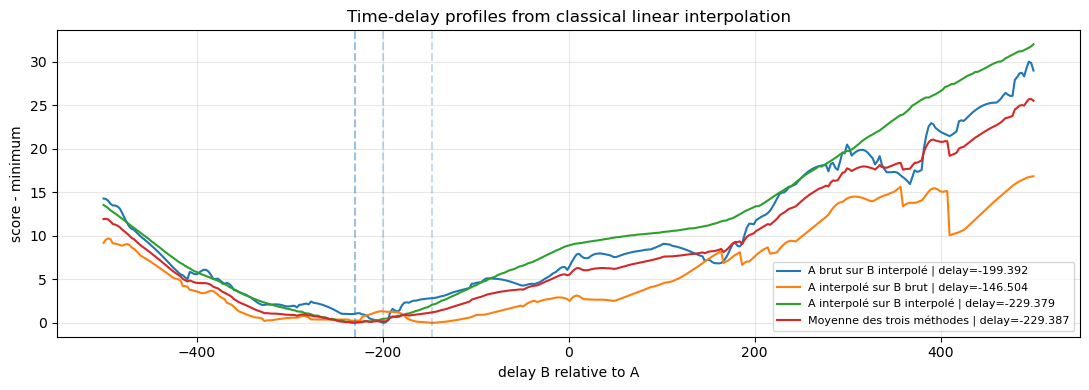

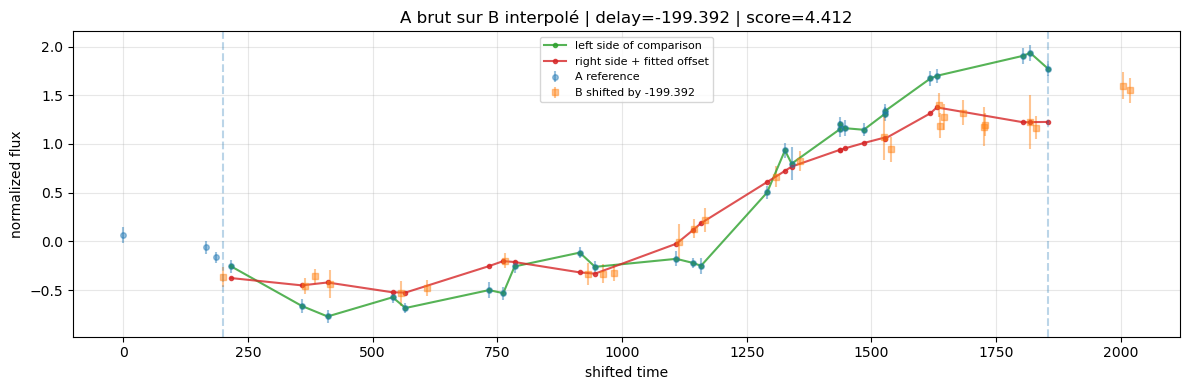

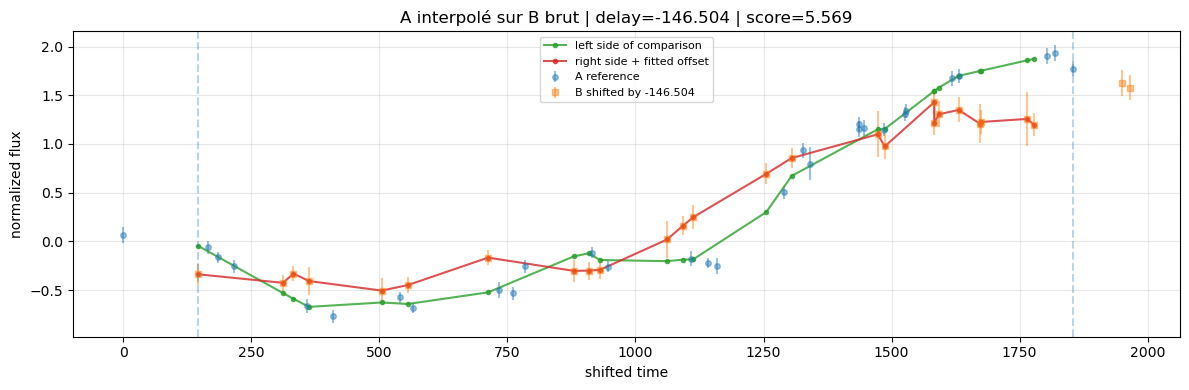

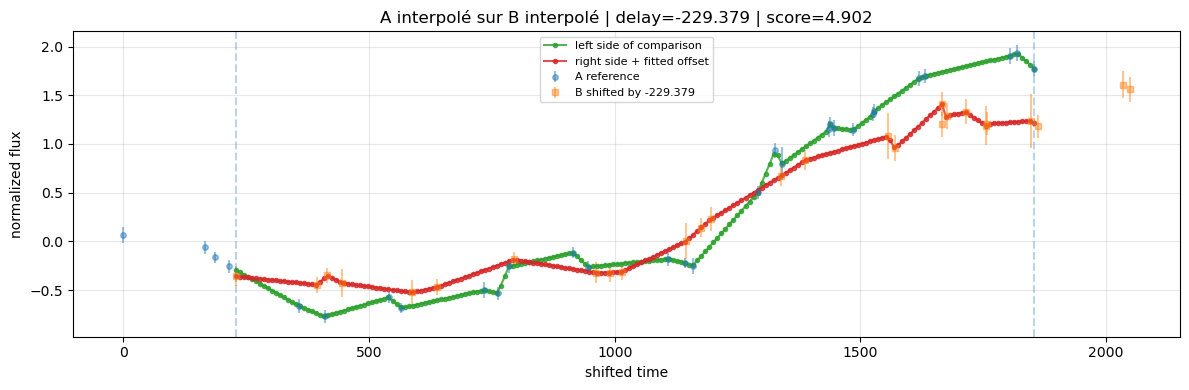

MC 100/1000 | valid=100/100
MC 200/1000 | valid=200/200
MC 300/1000 | valid=300/300
MC 400/1000 | valid=400/400
MC 500/1000 | valid=500/500
MC 600/1000 | valid=600/600
MC 700/1000 | valid=700/700
MC 800/1000 | valid=800/800
MC 900/1000 | valid=900/900
MC 1000/1000 | valid=1000/1000

===== UNCERTAINTY FROM FLUX_OBS_ERROR =====
This is Monte Carlo propagation, not MCMC on delay.
n samples: 1000
n valid: 1000
valid fraction: 1.0
error scale: 1.0

          method                       label  base_delay  n_valid      median         q16         q84  err_minus_16_84  err_plus_16_84       q02_5       q97_5        std
   raw_on_interp      A brut sur B interpolé -199.391780     1000 -199.833327 -200.112918 -196.335035         0.279591        3.498292 -327.347008  163.110319  85.432121
   interp_on_raw      A interpolé sur B brut -146.504222     1000 -130.458431 -323.970232   49.447177       193.511801      179.905608 -328.299589  110.390249 147.267611
interp_on_interp A interpolé sur B interpo

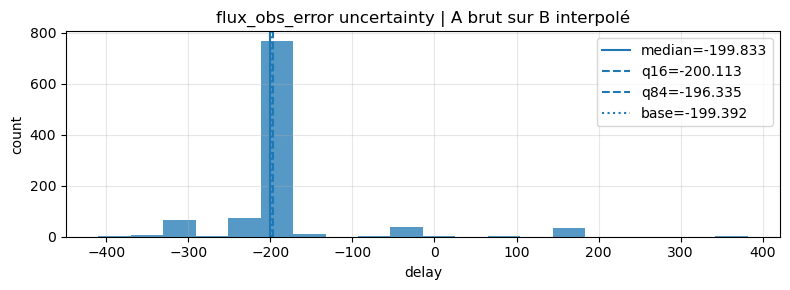

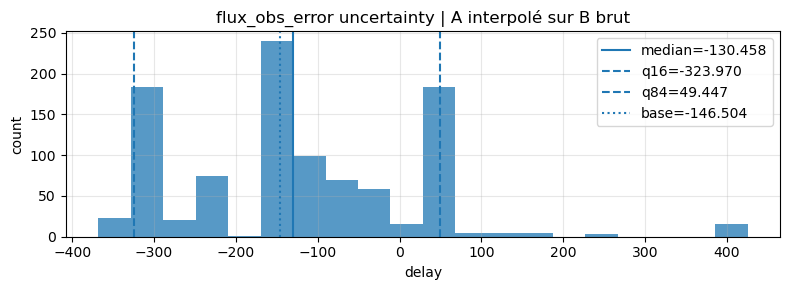

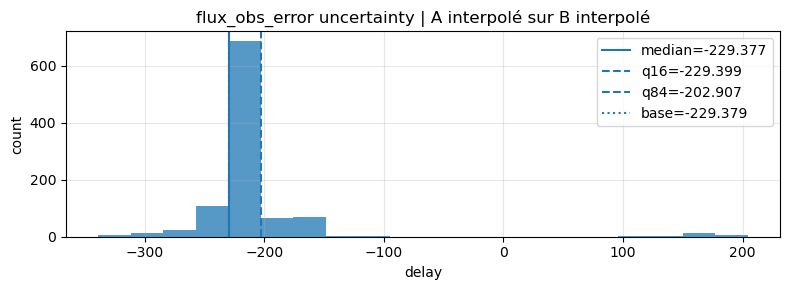

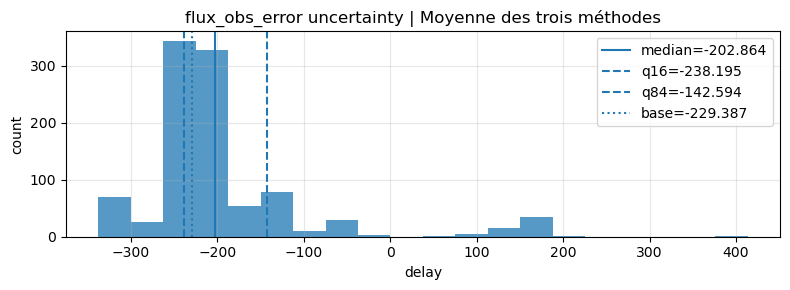

   n_valid      median         q16         q84  err_minus_16_84  \
0     1000 -199.833327 -200.112918 -196.335035         0.279591   
1     1000 -130.458431 -323.970232   49.447177       193.511801   
2     1000 -229.376877 -229.399135 -202.907313         0.022258   
3     1000 -202.863566 -238.194588 -142.594183        35.331022   

   err_plus_16_84       q02_5       q97_5         std            method  \
0        3.498292 -327.347008  163.110319   85.432121     raw_on_interp   
1      179.905608 -328.299589  110.390249  147.267611     interp_on_raw   
2       26.469565 -275.928574 -147.248945   63.162141  interp_on_interp   
3       60.269383 -327.327922  165.214938  102.886200          combined   

                         label  base_delay  
0       A brut sur B interpolé -199.391780  
1       A interpolé sur B brut -146.504222  
2  A interpolé sur B interpolé -229.378618  
3   Moyenne des trois méthodes -229.386966  


In [16]:
if __name__ == "__main__":
    ROOT = Path.cwd().parent
    INPUT_CSV = ROOT / "data" / "cleaned_lightcurves.csv"
    df = pd.read_csv(INPUT_CSV)

    SOURCE_ID = 3361094865862486656

    COMP_IDS = [
        3361094865862486721,  # A reference, delay = 0
        3361094865862486723,  # B
    ]

    NAMES = [
        "A reference",
        "B",
    ]

    system = get_pair_from_df(
        df,
        source_id=SOURCE_ID,
        comp_a=COMP_IDS[0],
        comp_b=COMP_IDS[1],
        names=NAMES,
    )

    estimator_kwargs = dict(
        dmin=-500,
        dmax=500,
        ngrid=400,

        # Classical regular grid used only for interpolated/interpolated.
        common_grid_size=200,

        # Fits one constant magnitude/flux offset for each comparison.
        fit_offset=True,

        # Minimum normalized measurement uncertainty.
        sigma_floor=0.05,

        # Overlap constraints.
        min_points=10,
        min_frac=0.50,
        min_span_frac=0.50,
        overlap_penalty=0.0,

        # Grid minimum followed by local bounded refinement.
        refine=True,
        scalar_xatol=0.05,
        verbose=True,
    )

    # ========================================================
    # 1) Fit on the original observations
    # ========================================================

    res = estimate_time_delay_linear_interpolation(
        system["curves"],
        **estimator_kwargs,
    )

    plot_delay_profiles_interpolation(res)
    plot_best_alignments_interpolation(res)

    # ========================================================
    # 2) Measurement uncertainty from flux_obs_error
    # ========================================================

    mc = run_fluxobs_error_mc_interpolation(
        system=system,
        estimator_kwargs=estimator_kwargs,
        base_res=res,
        n_samples=1000,
        random_seed=42,
        error_scale=1.0,
        progress_every=100,
        verbose=True,
    )

    print_fluxobs_error_mc_interpolation(mc)
    plot_fluxobs_error_mc_interpolation(mc, bins=20)

    mc_samples = mc["samples"]
    delay_summary = mc["summary"]

    print(delay_summary)


===== UNCERTAINTY FROM FLUX_OBS_ERROR =====
This is Monte Carlo propagation, not MCMC on delay.
n samples: 1000
n valid: 1000
valid fraction: 1.0
error scale: 1.0

          method                       label  base_delay  n_valid      median         q16         q84  err_minus_16_84  err_plus_16_84       q02_5       q97_5        std
   raw_on_interp      A brut sur B interpolé -199.391780     1000 -199.833327 -200.112918 -196.335035         0.279591        3.498292 -327.347008  163.110319  85.432121
   interp_on_raw      A interpolé sur B brut -146.504222     1000 -130.458431 -323.970232   49.447177       193.511801      179.905608 -328.299589  110.390249 147.267611
interp_on_interp A interpolé sur B interpolé -229.378618     1000 -229.376877 -229.399135 -202.907313         0.022258       26.469565 -275.928574 -147.248945  63.162141
        combined  Moyenne des trois méthodes -229.386966     1000 -202.863566 -238.194588 -142.594183        35.331022       60.269383 -327.327922  165.214

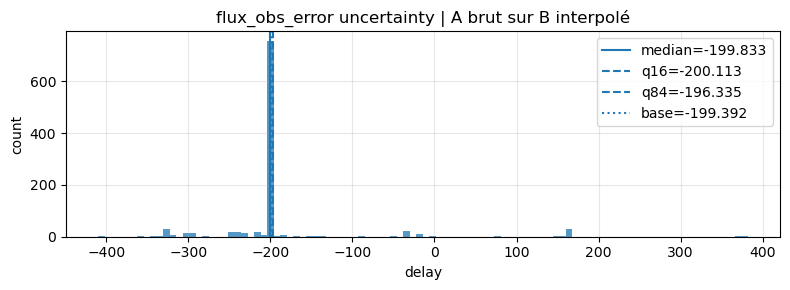

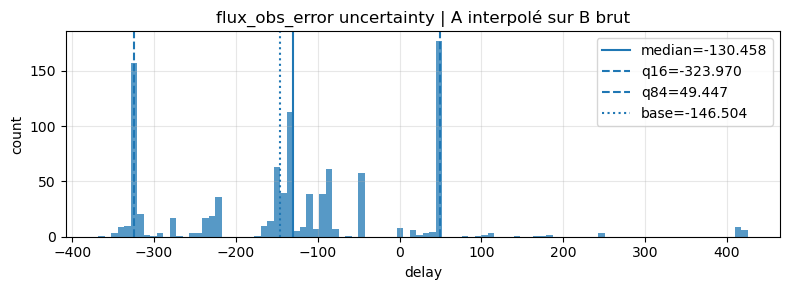

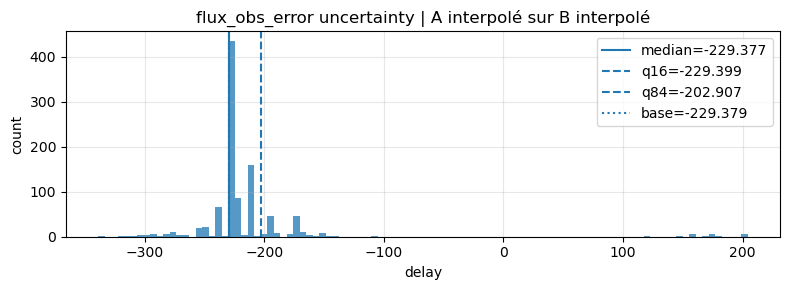

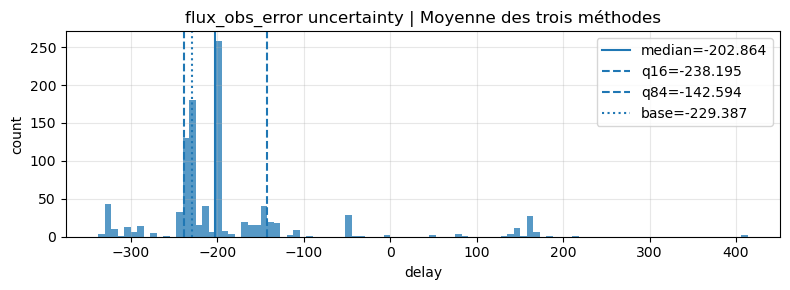

In [20]:
print_fluxobs_error_mc_interpolation(mc)
plot_fluxobs_error_mc_interpolation(mc, bins=100)